In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('data/Bengaluru_House_Data.csv')

print("Shape:", df.shape)
df.head()

Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [2]:
print("## Missing Values ##")
print(df.isnull().sum())

print("\n## Data Typees ##")
print(df.dtypes)

print("\n## Basic Statics ##")
print(df.describe())

print("\n## Unique Values in key columns ##")
print(f"Size unique values (sample): {df['size'].unique()[:10]}")
print(f"Area type unique: {df['area_type'].unique()}")
print(f"Total sqft sample: {df['total_sqft'].unique()[:10]}")


## Missing Values ##
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

## Data Typees ##
area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

## Basic Statics ##
               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000

## Unique Values in key columns ##
Size unique values (sample): ['2 BHK' '

In [3]:
# ── CLEANING ────────────────────────────────────────────────────────────────

# 1. Drop irrelevant columns
df = df.drop(['area_type', 'availability', 'society', 'balcony'], axis=1)

# 2. Drop rows with missing values
df = df.dropna()

# 3. Extract BHK count from size column
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]) if isinstance(x, str) else 0)
df = df.drop('size', axis=1)

# 4. Fix total_sqft — handle ranges like "1000-1200"
def convert_sqft(x):
    try:
        if '-' in str(x):
            parts = x.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna(subset=['total_sqft'])

# 5. Remove outliers
df = df[df['bath'] < 10]
df = df[df['price'] < 500]
df = df[df['total_sqft'] < 10000]
df = df[df['bhk'] <= 6]

# 6. Price per sqft outlier removal
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']
df = df[(df['price_per_sqft'] > 1000) & (df['price_per_sqft'] < 100000)]
df = df.drop(['location', 'price_per_sqft'], axis=1)

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (12676, 4)


,total_sqft,bath,price,bhk
0,1056.0,2.0,39.07,2
1,2600.0,5.0,120.00,4
2,1440.0,2.0,62.00,3
3,1521.0,3.0,95.00,3
4,1200.0,2.0,51.00,2


In [4]:
# ── REALISTIC KERALA SYNTHETIC DATA ─────────────────────────────────────────
np.random.seed(42)
n = 3000

# Base features
bhk         = np.random.choice([2, 2, 2, 3, 3], n)
total_sqft  = np.where(bhk == 2,
                np.random.normal(850, 80, n),
                np.random.normal(1100, 100, n)).clip(650, 1400)
bath        = np.where(bhk == 2, 2.0, 3.0)
plot_cents  = np.random.uniform(2.5, 4.5, n)
has_garden  = np.random.choice([0, 1], n, p=[0.3, 0.7])
has_aquarium= np.random.choice([0, 1], n, p=[0.5, 0.5])
finishing   = np.random.choice([1, 2, 3], n, p=[0.3, 0.4, 0.3])

# Realistic Kerala price formula (in lakhs)
# Based on actual Kerala small-plot construction economics
base_construction_cost = total_sqft * 0.18          # ~₹1800/sqft construction
plot_value             = plot_cents * 4.5            # land value per cent
garden_premium         = has_garden * 1.8            # garden adds value
aquarium_premium       = has_aquarium * 1.2          # aquarium adds value
finishing_premium      = (finishing - 1) * 4.0       # premium finishing
bhk_premium            = (bhk - 2) * 5.0            # extra bedroom value
noise                  = np.random.normal(0, 2, n)   # market variation

price = (base_construction_cost + plot_value + garden_premium +
         aquarium_premium + finishing_premium + bhk_premium + noise).clip(18, 65)

kerala_df = pd.DataFrame({
    'total_sqft'      : total_sqft,
    'bath'            : bath,
    'bhk'             : bhk,
    'plot_size_cents' : plot_cents,
    'has_garden'      : has_garden,
    'has_aquarium'    : has_aquarium,
    'finishing_level' : finishing,
    'price'           : price
})

# ── ADD KERALA FEATURES TO BANGALORE DATA ───────────────────────────────────
# Bangalore data gets neutral defaults since we don't have these features
np.random.seed(99)
df['plot_size_cents'] = np.random.uniform(2.5, 4.5, len(df))
df['has_garden']      = np.random.choice([0, 1], len(df), p=[0.4, 0.6])
df['has_aquarium']    = np.random.choice([0, 1], len(df), p=[0.6, 0.4])
df['finishing_level'] = np.random.choice([1, 2, 3], len(df), p=[0.3, 0.4, 0.3])

# ── COMBINE ──────────────────────────────────────────────────────────────────
combined = pd.concat([df, kerala_df], ignore_index=True)
combined  = combined.reset_index(drop=True)

print("Combined shape:", combined.shape)
print("\nFeature stats:")
print(combined.describe().round(2))

Combined shape: (15676, 8)

Feature stats:
       total_sqft      bath     price       bhk  plot_size_cents  has_garden  \
count    15676.00  15676.00  15676.00  15676.00         15676.00    15676.00   
mean      1363.97      2.53     89.63      2.61             3.51        0.62   
std        660.35      0.93     69.56      0.87             0.57        0.49   
min         45.00      1.00      8.00      1.00             2.50        0.00   
25%       1000.00      2.00     53.94      2.00             3.01        0.00   
50%       1200.00      2.00     65.00      2.00             3.52        1.00   
75%       1517.25      3.00     95.00      3.00             4.00        1.00   
max       9000.00      9.00    499.00      6.00             4.50        1.00   

       has_aquarium  finishing_level  
count      15676.00         15676.00  
mean           0.42             2.00  
std            0.49             0.78  
min            0.00             1.00  
25%            0.00             1.00  
50

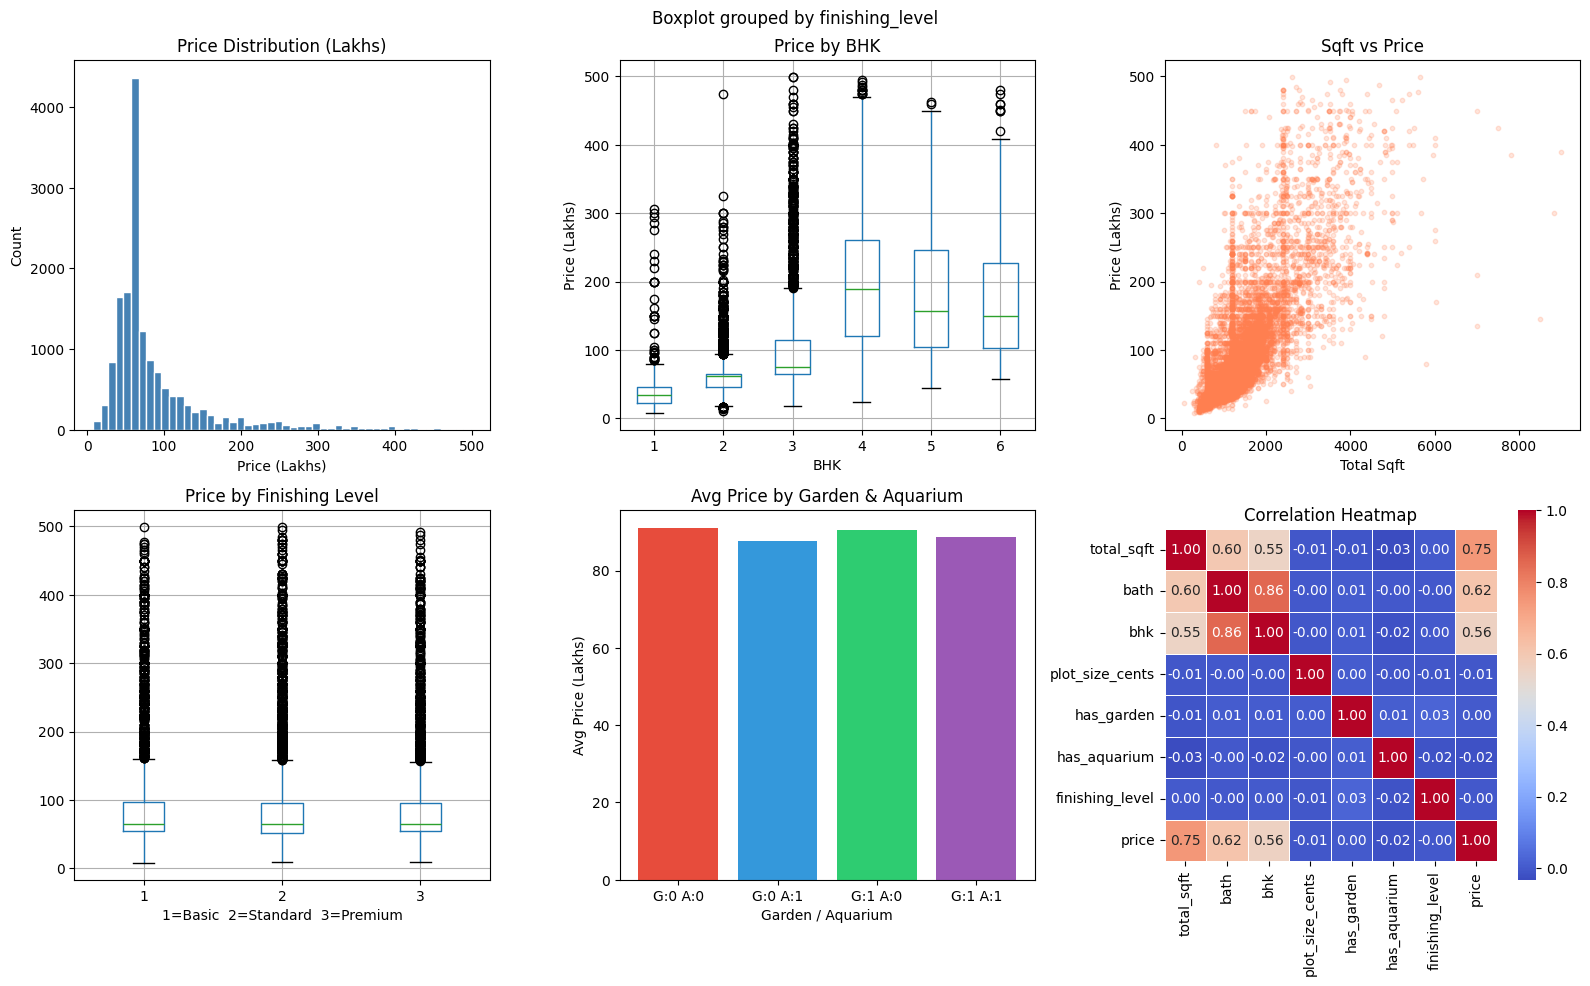

EDA plots saved to data/eda_plots.png


In [5]:
# ── EDA VISUALISATIONS ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('BuildSense AI — Dataset EDA', fontsize=16, fontweight='bold')

# 1. Price distribution
axes[0,0].hist(combined['price'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution (Lakhs)')
axes[0,0].set_xlabel('Price (Lakhs)')
axes[0,0].set_ylabel('Count')

# 2. BHK vs Price
combined.boxplot(column='price', by='bhk', ax=axes[0,1])
axes[0,1].set_title('Price by BHK')
axes[0,1].set_xlabel('BHK')
axes[0,1].set_ylabel('Price (Lakhs)')
plt.sca(axes[0,1])
plt.title('Price by BHK')

# 3. Sqft vs Price
axes[0,2].scatter(combined['total_sqft'], combined['price'], 
                  alpha=0.2, color='coral', s=10)
axes[0,2].set_title('Sqft vs Price')
axes[0,2].set_xlabel('Total Sqft')
axes[0,2].set_ylabel('Price (Lakhs)')

# 4. Finishing level vs Price
combined.boxplot(column='price', by='finishing_level', ax=axes[1,0])
axes[1,0].set_title('Price by Finishing Level')
axes[1,0].set_xlabel('1=Basic  2=Standard  3=Premium')
plt.sca(axes[1,0])
plt.title('Price by Finishing Level')

# 5. Garden & Aquarium impact
impact_data = combined.groupby(['has_garden', 'has_aquarium'])['price'].mean().reset_index()
labels = [f"G:{int(r.has_garden)} A:{int(r.has_aquarium)}" for _, r in impact_data.iterrows()]
axes[1,1].bar(labels, impact_data['price'], color=['#e74c3c','#3498db','#2ecc71','#9b59b6'])
axes[1,1].set_title('Avg Price by Garden & Aquarium')
axes[1,1].set_ylabel('Avg Price (Lakhs)')
axes[1,1].set_xlabel('Garden / Aquarium')

# 6. Correlation heatmap
corr = combined[['total_sqft','bath','bhk','plot_size_cents',
                 'has_garden','has_aquarium','finishing_level','price']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=axes[1,2], 
            cmap='coolwarm', square=True, linewidths=0.5)
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('data/eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA plots saved to data/eda_plots.png")

In [6]:
# ── TRAIN / TEST SPLIT + PREPROCESSING ──────────────────────────────────────
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
import shap
import joblib
import os

# Features and target
FEATURES = ['total_sqft', 'bath', 'bhk', 'plot_size_cents',
            'has_garden', 'has_aquarium', 'finishing_level']
TARGET = 'price'

X = combined[FEATURES]
y = combined[TARGET]

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {FEATURES}")

Training samples : 12540
Test samples     : 3136
Features         : ['total_sqft', 'bath', 'bhk', 'plot_size_cents', 'has_garden', 'has_aquarium', 'finishing_level']


In [7]:
# ── MLFLOW SETUP ─────────────────────────────────────────────────────────────
mlflow.set_experiment("buildsense_cost_prediction")

# ── OPTUNA HYPERPARAMETER TUNING ─────────────────────────────────────────────
def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 1000),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state'    : 42,
        'tree_method'     : 'hist'
    }

    model = xgb.XGBRegressor(**params)

    # 5-fold cross validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error')
    return scores.mean()

print("Starting Optuna hyperparameter tuning — 50 trials...")
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_params['random_state'] = 42
best_params['tree_method'] = 'hist'

print(f"\nBest RMSE (CV): {-study.best_value:.4f} lakhs")
print(f"Best params: {best_params}")

[I 2026-06-21 21:25:03,598] A new study created in memory with name: no-name-74f8f598-0f52-43cc-941a-0a014ef7b4c9


Starting Optuna hyperparameter tuning — 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-21 21:25:15,650] Trial 0 finished with value: -45.47658779959229 and parameters: {'n_estimators': 437, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_alpha': 2.9152036385288193e-08, 'reg_lambda': 0.08499808989182997}. Best is trial 0 with value: -45.47658779959229.
[I 2026-06-21 21:25:27,061] Trial 1 finished with value: -41.27195548783128 and parameters: {'n_estimators': 641, 'max_depth': 8, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 3, 'reg_alpha': 2.8483918709107956e-07, 'reg_lambda': 2.9324868872723725e-07}. Best is trial 1 with value: -41.27195548783128.
[I 2026-06-21 21:25:32,288] Trial 2 finished with value: -42.047295630902795 and parameters: {'n_estimators': 374, 'max_depth': 7, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.84

In [8]:
# ── TRAIN FINAL MODEL WITH BEST PARAMS ──────────────────────────────────────
with mlflow.start_run(run_name="xgboost_buildsense_v1"):

    # Train final model
    final_model = xgb.XGBRegressor(**best_params)
    final_model.fit(X_train, y_train,
                    eval_set=[(X_test, y_test)],
                    verbose=False)

    # Predictions
    y_pred = final_model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    # Log to MLflow
    mlflow.log_params(best_params)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae",  mae)
    mlflow.log_metric("r2",   r2)
    mlflow.xgboost.log_model(final_model, "model")

    print("=" * 40)
    print("FINAL MODEL EVALUATION")
    print("=" * 40)
    print(f"RMSE : {rmse:.2f} lakhs")
    print(f"MAE  : {mae:.2f} lakhs")
    print(f"R²   : {r2:.4f}")
    print("=" * 40)

    # Feature importance
    importance = pd.DataFrame({
        'feature'   : FEATURES,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nFeature Importance:")
    print(importance.to_string(index=False))

2026/06/21 21:29:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


FINAL MODEL EVALUATION
RMSE : 40.04 lakhs
MAE  : 23.20 lakhs
R²   : 0.6393

Feature Importance:
        feature  importance
     total_sqft    0.502740
           bath    0.257394
            bhk    0.175224
plot_size_cents    0.022494
   has_aquarium    0.016140
finishing_level    0.014247
     has_garden    0.011762


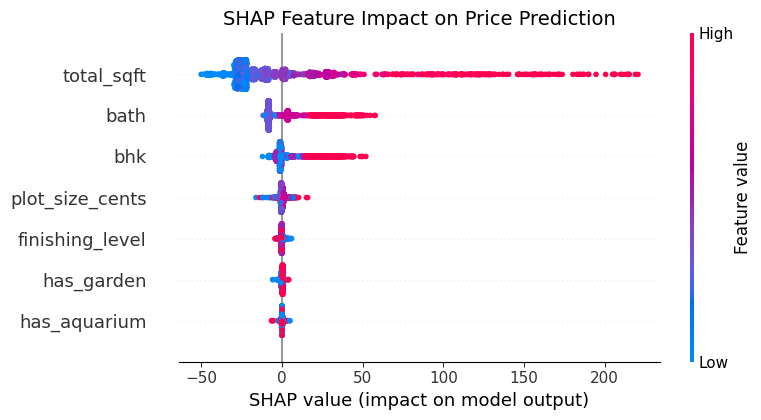

SHAP plot saved.

--- SHAP explanation for a sample Kerala house ---
Predicted price: 56.84 lakhs

SHAP contribution per feature:
  total_sqft          : decreases price by 24.47 lakhs
  bath                : decreases price by 8.10 lakhs
  bhk                 : decreases price by 0.80 lakhs
  plot_size_cents     : decreases price by 0.11 lakhs
  has_garden          : increases price by 0.35 lakhs
  has_aquarium        : increases price by 0.10 lakhs
  finishing_level     : decreases price by 0.18 lakhs


In [9]:
# ── SHAP ANALYSIS ────────────────────────────────────────────────────────────
# Fix for XGBoost 2.x + SHAP compatibility
booster = final_model.get_booster()
booster.set_attr(base_score=None)

explainer   = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES,
                  show=False)
plt.title('SHAP Feature Impact on Price Prediction', fontsize=14)
plt.tight_layout()
plt.savefig('data/shap_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print("SHAP plot saved.")

# SHAP for a single Kerala prediction
print("\n--- SHAP explanation for a sample Kerala house ---")
sample = pd.DataFrame([{
    'total_sqft'      : 900,
    'bath'            : 2,
    'bhk'             : 2,
    'plot_size_cents' : 3.5,
    'has_garden'      : 1,
    'has_aquarium'    : 1,
    'finishing_level' : 2
}])

predicted_price = final_model.predict(sample)[0]
sample_shap     = explainer.shap_values(sample)

print(f"Predicted price: {predicted_price:.2f} lakhs")
print("\nSHAP contribution per feature:")
for feat, val in zip(FEATURES, sample_shap[0]):
    direction = "increases" if val > 0 else "decreases"
    print(f"  {feat:20s}: {direction} price by {abs(val):.2f} lakhs")

In [10]:
# ── SAVE MODEL ───────────────────────────────────────────────────────────────
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(final_model, 'models/cost_predictor.pkl')

# Save feature list
import json
with open('models/features.json', 'w') as f:
    json.dump(FEATURES, f)

print("Model saved to models/cost_predictor.pkl")
print("Features saved to models/features.json")

# Test loading
loaded_model = joblib.load('models/cost_predictor.pkl')
test_pred = loaded_model.predict(sample)[0]
print(f"\nLoad test prediction: {test_pred:.2f} lakhs")
print("Model loading works correctly.")

Model saved to models/cost_predictor.pkl
Features saved to models/features.json

Load test prediction: 56.84 lakhs
Model loading works correctly.
